## Analysis of Causal Results

In [1]:
def default_params(): 
    return {
        'input_path' : '/workspaces/CodeSmells/data/extension/causality/results',
        'output_plots' : '/workspaces/CodeSmells/notebooks/extension/causal_analysis/correlation_plots',
        'treatment' : 'T2',
    }
params = default_params()

### Imports

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [3]:
def create_folder(path):
    if not os.path.exists(path):
        os.makedirs(path)

### Dataset loading

In [4]:
# #code_smell_actual_prob_median, #code_smell_max_prob_median, #code_smell_min_prob_median, 
# #code_smell_actual_prob_mean, #code_smell_max_prob_mean, #code_smell_min_prob_mean, 
# #code_smell_psc_entropy, #code_smell_psc_relative,
causal_results_per_smell_dict = {
    'code_smell_psc_relative' : pd.read_json(f"{params['input_path']}/{params['treatment']}/['code_smell_psc_relative'].json"),
}
#causal_results_dict = {
#    'code_smell_psc_relative' : pd.read_json(f"{params['input_path']}/{params['treatment']}/['code_smell_psc_relative']_ALL.json"),
#}

In [5]:
causal_results_per_smell_dict['code_smell_psc_relative'].sort_values(by=['estimated_effect'], ascending=False)

,method_name,pearson_corr,spearman_corr,kendall_corr,estimated_effect,refutation_placebo_permute,refutation_unobserved_confounder,refutation_subset,intervention,s_msg_id
69,backdoor.propensity_score_matching,0.050737,0.078153,0.064252,0.315322,"{'result': {'p_value': 0.8200000000000001, 'is...","{'result': None, 'new_effect': [0.2909741655, ...","{'result': {'p_value': 0.26, 'is_statistically...",S3,W0613
66,backdoor.propensity_score_matching,0.046314,0.086074,0.070810,0.313873,"{'result': {'p_value': 0.92, 'is_statistically...","{'result': None, 'new_effect': [0.2897697333, ...","{'result': {'p_value': 0.32, 'is_statistically...",S4,W0613
84,backdoor.propensity_score_matching,0.120220,0.125845,0.103110,0.208992,"{'result': {'p_value': 1.0, 'is_statistically_...","{'result': None, 'new_effect': [0.1781849563, ...","{'result': {'p_value': 0.52, 'is_statistically...",S4,C0304
63,backdoor.propensity_score_matching,0.027443,0.048331,0.039752,0.203220,"{'result': {'p_value': 0.96, 'is_statistically...","{'result': None, 'new_effect': [0.176971451500...","{'result': {'p_value': 0.36, 'is_statistically...",S2,W0613
147,backdoor.propensity_score_matching,0.131570,0.136802,0.112261,0.198778,"{'result': {'p_value': 0.98, 'is_statistically...","{'result': None, 'new_effect': [0.1813657606, ...","{'result': {'p_value': 0.46, 'is_statistically...",S4,C0321
...,...,...,...,...,...,...,...,...,...,...
171,backdoor.propensity_score_matching,0.039136,0.040897,0.033414,-0.082608,"{'result': {'p_value': 1.0, 'is_statistically_...","{'result': None, 'new_effect': [-0.0925186055,...","{'result': {'p_value': 0.38, 'is_statistically...",S2,R0914
81,backdoor.propensity_score_matching,0.046474,0.049673,0.040681,-0.088695,"{'result': {'p_value': 0.8, 'is_statistically_...","{'result': None, 'new_effect': [-0.09395122610...","{'result': {'p_value': 0.54, 'is_statistically...",S2,C0304
177,backdoor.propensity_score_matching,0.022776,0.032798,0.026797,-0.104029,"{'result': {'p_value': 0.9400000000000001, 'is...","{'result': None, 'new_effect': [-0.1081926094,...","{'result': {'p_value': 0.26, 'is_statistically...",S3,R0914
120,backdoor.propensity_score_matching,0.068074,0.077993,0.064123,-0.106973,"{'result': {'p_value': 0.9, 'is_statistically_...","{'result': None, 'new_effect': [-0.1716346006,...","{'result': {'p_value': 0.4, 'is_statistically_...",S4,W0622


In [6]:
causal_results_per_smell_dict['code_smell_psc_relative'].groupby(['intervention', 's_msg_id']).describe()

pearson_corr                                    \
                             count      mean           std       min   
intervention s_msg_id                                                  
S2           C0103             3.0  0.042458  0.000000e+00  0.042458   
             C0114             3.0 -0.003899  0.000000e+00 -0.003899   
             C0116             3.0  0.058114  0.000000e+00  0.058114   
             C0123             3.0  0.049118  0.000000e+00  0.049118   
             C0200             3.0  0.243056  0.000000e+00  0.243056   
...                            ...       ...           ...       ...   
S4           W0718             3.0  0.091883  0.000000e+00  0.091883   
             W0719             3.0  0.103672  0.000000e+00  0.103672   
             W1309             3.0  0.101468  1.699675e-17  0.101468   
             W1406             3.0  0.096607  0.000000e+00  0.096607   
             W1514             3.0  0.082091  0.000000e+00  0.082091   

                                                              spearman_corr  \
                            25%       50%       75%       max         count   
intervention s_msg_id                                                         
S2           C0103     0.042458  0.042458  0.042458  0.042458           3.0   
             C0114    -0.003899 -0.003899 -0.003899 -0.003899           3.0   
             C0116     0.058114  0.058114  0.058114  0.058114           3.0   
             C0123     0.049118  0.049118  0.049118  0.049118           3.0   
             C0200     0.243056  0.243056  0.243056  0.243056           3.0   
...                         ...       ...       ...       ...           ...   
S4           W0718     0.091883  0.091883  0.091883  0.091883           3.0   
             W0719     0.103672  0.103672  0.103672  0.103672           3.0   
             W1309     0.101468  0.101468  0.101468  0.101468           3.0   
             W1406     0.096607  0.096607  0.096607  0.096607           3.0   
             W1514     0.082091  0.082091  0.082091  0.082091           3.0   

                                 ... kendall_corr           estimated_effect  \
                           mean  ...          75%       max            count   
intervention s_msg_id            ...                                           
S2           C0103     0.047859  ...     0.039279  0.039279              3.0   
             C0114    -0.011702  ...    -0.009559 -0.009559              3.0   
             C0116     0.024720  ...     0.020194  0.020194              3.0   
             C0123     0.047374  ...     0.038765  0.038765              3.0   
             C0200     0.268638  ...     0.219465  0.219465              3.0   
...                         ...  ...          ...       ...              ...   
S4           W0718     0.108948  ...     0.090829  0.090829              3.0   
             W0719     0.104107  ...     0.085081  0.085081              3.0   
             W1309     0.096556  ...     0.079113  0.079113              3.0   
             W1406     0.102520  ...     0.084076  0.084076              3.0   
             W1514     0.085916  ...     0.070570  0.070570              3.0   

                                                                         \
                           mean       std       min       25%       50%   
intervention s_msg_id                                                     
S2           C0103     0.027550  0.009544  0.016530  0.024795  0.033060   
             C0114    -0.010277  0.015716 -0.028424 -0.014814 -0.001204   
             C0116     0.017695  0.003708  0.015554  0.015554  0.015554   
             C0123     0.025171  0.005396  0.022056  0.022056  0.022056   
             C0200     0.031978  0.008175  0.022539  0.029618  0.036698   
...                         ...       ...       ...       ...       ...   
S4           W0718     0.041104  0.014195  0.024713  0.037006  0.049299   
             W0719     0.020466  0.

### Plots

In [ ]:
def plot_correlations(causal_df, outcome, correlation, method_name, intervention):
    # Transforming the DataFrame using melt
    causal_df = causal_df[
        (causal_df['method_name'] == method_name) &(causal_df['intervention'] == intervention)
    ].copy()
    correlation_plot_df = causal_df.melt(id_vars=['s_msg_id'], value_vars=[correlation, 'estimated_effect'],  var_name='type', value_name='value')

    # Create the plot
    plt.figure(figsize=(40, 6))
    barplot = sns.barplot(
        palette='mako',
        data=correlation_plot_df,
        x="s_msg_id",
        y="value",
        hue="type",
        alpha=0.8,
        errorbar=None)

    # Improve x-axis readability
    plt.xlabel("Smell Id", fontsize=12)
    plt.ylabel("Value", fontsize=12)
    plt.title(f"{correlation} vs ATE. Outcome [{outcome}], Treatment [{intervention}]", fontsize=14)

    # Move the legend outside for clarity
    plt.legend(title="Metrics", bbox_to_anchor=(1.05, 1), loc='upper left')

    output_dir = f"{params['output_plots']}/{params['treatment']}/{intervention}/{method_name}"
    create_folder(output_dir)
    plt.savefig(f"{output_dir}/{outcome}_{correlation}.png", bbox_inches="tight", dpi=300)
    plt.close()



KeyboardInterrupt: 

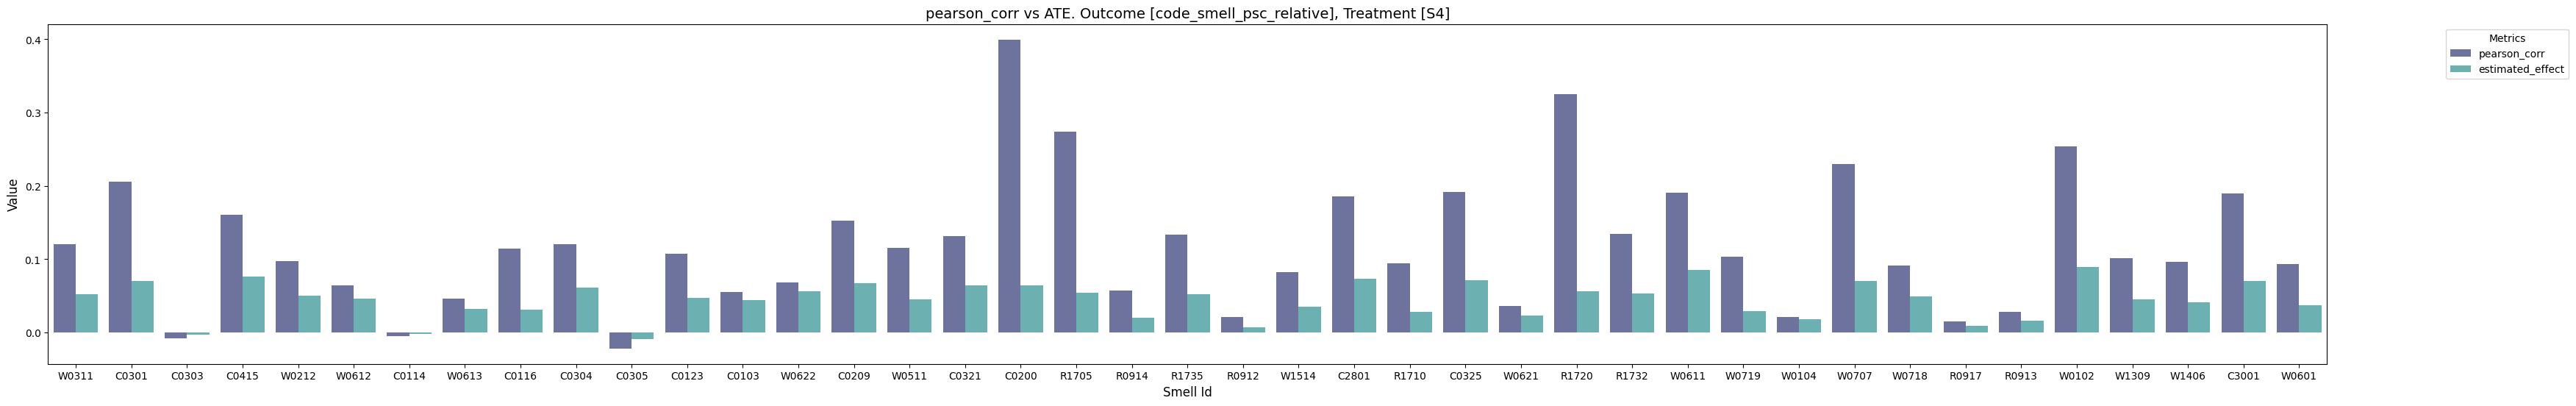

In [8]:
method_names = ['backdoor.generalized_linear_model', 'backdoor.propensity_score_matching', 'backdoor.propensity_score_stratification', 'backdoor.propensity_score_weighting']

for outcome, causal_df in causal_results_per_smell_dict.items():
    for correlation in ['pearson_corr', 'spearman_corr', 'kendall_corr']:
        for method_name in method_names:
            for intervention in causal_df['intervention'].unique():
                plot_correlations(causal_df, outcome, correlation, method_name, intervention)